# Create BPA WHEN and WHERE datasets across event-window sizes

Create paired BPA datasets for 0.25-hour, 0.5-hour, and 1- through 12-hour event windows in the same finalized format as NYISO. The workflow normalizes BPA columns, builds graph-community zones, creates aligned WHEN/WHERE samples, assigns folds, classifies background samples, writes both CSV files for every window size, and validates them.

## Configuration

In [1]:
from __future__ import annotations

import csv
import json
import random
import re
from collections import Counter
from datetime import timedelta
from pathlib import Path

import igraph as ig
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from sklearn.model_selection import KFold, train_test_split
from tqdm import tqdm

INPUT_PATH = Path("bpa_processed.csv")
OUTPUT_DIR = Path("output")
RES_DIR = Path("res")
GRAPH_PATH = RES_DIR / "outage_graph.pkl"
EDGE_ZONE_PATH = OUTPUT_DIR / "edge_zones.csv"

EVENT_WINDOW_HOURS_VALUES = [0.25, 0.5, *range(1, 13)]
MIN_YEAR = 2008
MAX_EVENTS_PER_WINDOW = 200
RANDOM_SEED = 42

# Keep these columns identical to the NYISO WHEN dataset.
VOLTAGE_GROUPS = [69, 115, 132, 220, 345, 500, 735]
INTERVALS_MINUTES = [15, 30, 60, 120]
WHERE_INTERVALS = [
    timedelta(minutes=15),
    timedelta(minutes=30),
    timedelta(minutes=60),
    timedelta(minutes=120),
    timedelta(days=10),
]

FEATURE_COLUMNS = [
    "num_events",
    "num_unique_ptids",
    *[f"num_{voltage}kv_lines" for voltage in VOLTAGE_GROUPS],
    "num_planned_outages",
    "num_auto_outages",
    "num_unique_buses",
    *[f"num_events_last_{minutes}_min" for minutes in INTERVALS_MINUTES],
    "node_degree_mean",
    "node_degree_std",
    "node_degree_min",
    "node_degree_max",
    *[f"last_planned_voltage_{voltage}kv" for voltage in VOLTAGE_GROUPS],
    "last_planned_node_degree_mean",
]
LABEL_COLUMNS = [
    "label_is_auto",
    "label_time_to_event_seconds",
    "label_from_zone",
    "label_to_zone",
]
WHEN_COLUMNS = ["fold_id", *FEATURE_COLUMNS, *LABEL_COLUMNS, "is_bg"]

## Normalize BPA outage records

In [2]:
def normalize_bus_name(value: object) -> str | None:
    """Return a stable BPA bus name, or ``None`` for failed extractions."""
    if pd.isna(value):
        return None

    bus_name = re.sub(r"\s+", " ", str(value).strip()).upper()
    if not bus_name or bus_name == "---":
        return None
    return bus_name


def coalesce_columns(frame: pd.DataFrame, primary: str, fallback: str) -> pd.Series:
    """Use ``fallback`` wherever the version-specific ``primary`` is absent."""
    return frame[primary].combine_first(frame[fallback])


def normalize_bpa_events(input_path: Path) -> tuple[pd.DataFrame, int]:
    """Normalize BPA records into the fields used by the NYISO generator."""
    raw = pd.read_csv(input_path, low_memory=False)

    events = pd.DataFrame(index=raw.index)
    events["out_datetime"] = pd.to_datetime(
        coalesce_columns(raw, "Out Datetime", "Out Datetime (PPT)"),
        format="mixed",
        errors="coerce",
    )
    events["in_datetime"] = pd.to_datetime(
        coalesce_columns(raw, "In Datetime", "In Datetime (PPT)"),
        format="mixed",
        errors="coerce",
    )
    events["line_id"] = raw["Name"].astype("string")
    events["voltage"] = pd.to_numeric(
        coalesce_columns(raw, "Voltage (kV)", "Kilovolt"), errors="coerce"
    )
    events["first_bus"] = raw["First Bus"].map(normalize_bus_name)
    events["second_bus"] = raw["Second Bus"].map(normalize_bus_name)
    events["outage_type"] = raw["Outage Type"].replace({"Plan": "Planned"})

    valid = (
        events["out_datetime"].notna()
        & events["voltage"].notna()
        & events["line_id"].notna()
        & events["first_bus"].notna()
        & events["second_bus"].notna()
        & events["outage_type"].isin(["Planned", "Auto"])
        & (events["out_datetime"].dt.year >= MIN_YEAR)
    )
    dropped_rows = int((~valid).sum())
    events = events.loc[valid].copy()

    # A stable sort preserves the source ordering for simultaneous line records.
    events.sort_values("out_datetime", kind="stable", inplace=True)
    events.reset_index(drop=True, inplace=True)
    return events, dropped_rows

## Build the outage graph and zone mapping

In [3]:
def build_outage_graph(
    events: pd.DataFrame, seed: int = RANDOM_SEED
) -> tuple[ig.Graph, dict[str, int], dict[str, int]]:
    """Build the BPA bus graph and assign deterministic Leiden zone IDs."""
    bus_names = sorted(set(events["first_bus"]) | set(events["second_bus"]))
    bus_name_to_index = {bus_name: index for index, bus_name in enumerate(bus_names)}

    # Use one undirected edge per bus pair, as in the NYISO graph construction.
    edge_set = {
        tuple(
            sorted(
                (
                    bus_name_to_index[first_bus],
                    bus_name_to_index[second_bus],
                )
            )
        )
        for first_bus, second_bus in zip(events["first_bus"], events["second_bus"])
    }
    graph = ig.Graph(n=len(bus_names), edges=sorted(edge_set), directed=False)

    # python-igraph uses this RNG for Leiden's randomized initialization.
    ig.set_random_number_generator(random.Random(seed))
    communities = graph.community_leiden(objective_function="modularity")
    community_sizes = Counter(communities.membership)
    ordered_communities = sorted(
        community_sizes, key=lambda community: (-community_sizes[community], community)
    )
    community_to_zone = {
        community: zone for zone, community in enumerate(ordered_communities)
    }
    bus_to_zone = {
        bus_name: community_to_zone[communities.membership[bus_index]]
        for bus_name, bus_index in bus_name_to_index.items()
    }
    return graph, bus_name_to_index, bus_to_zone


def voltage_group(voltage: float) -> int:
    """Map BPA nominal voltages to the nearest NYISO voltage feature group."""
    return min(VOLTAGE_GROUPS, key=lambda group: (abs(group - voltage), group))


def row_zones(row: pd.Series, bus_to_zone: dict[str, int]) -> tuple[int, int]:
    return bus_to_zone[row["first_bus"]], bus_to_zone[row["second_bus"]]

## Create aligned WHEN and WHERE samples

In [4]:
def create_when_sample(
    auto_outage: pd.Series,
    window: list[pd.Series],
    last_scheduled: pd.Series,
    graph: ig.Graph,
    bus_name_to_index: dict[str, int],
    bus_to_zone: dict[str, int],
) -> tuple[list[object], list[object]]:
    """Create one BPA WHEN sample with the NYISO feature and label layout."""
    voltage_counts = Counter(voltage_group(float(row["voltage"])) for row in window)
    bus_names = [
        row[bus_column] for row in window for bus_column in ("first_bus", "second_bus")
    ]

    fine_interval_features = [
        sum(
            auto_outage["out_datetime"] - row["out_datetime"]
            < timedelta(minutes=minutes)
            for row in window
        )
        for minutes in INTERVALS_MINUTES
    ]

    node_degrees = np.asarray(
        [graph.degree(bus_name_to_index[bus_name]) for bus_name in bus_names],
        dtype=float,
    )
    last_planned_degrees = np.asarray(
        [
            graph.degree(bus_name_to_index[last_scheduled[bus_column]])
            for bus_column in ("first_bus", "second_bus")
        ],
        dtype=float,
    )
    last_planned_voltage_group = voltage_group(float(last_scheduled["voltage"]))

    features: list[object] = [
        len(window),
        len({row["line_id"] for row in window}),
        *[voltage_counts[group] for group in VOLTAGE_GROUPS],
        sum(row["outage_type"] == "Planned" for row in window),
        sum(row["outage_type"] == "Auto" for row in window),
        len(set(bus_names)),
        *fine_interval_features,
        float(node_degrees.mean()),
        float(node_degrees.std()),
        int(node_degrees.min()),
        int(node_degrees.max()),
        *[int(group == last_planned_voltage_group) for group in VOLTAGE_GROUPS],
        float(last_planned_degrees.mean()),
    ]

    from_zone, to_zone = row_zones(auto_outage, bus_to_zone)
    time_to_event = auto_outage["out_datetime"] - max(
        row["out_datetime"] for row in window
    )
    labels: list[object] = [
        True,
        float(time_to_event.total_seconds()),
        from_zone,
        to_zone,
    ]
    return features, labels


def get_delta_index(last_scheduled: pd.Series, row: pd.Series) -> int:
    delta = last_scheduled["out_datetime"] - row["out_datetime"]
    return next(
        (index for index, interval in enumerate(WHERE_INTERVALS) if delta < interval),
        len(WHERE_INTERVALS) - 1,
    )


def create_where_sample(
    auto_outage: pd.Series,
    window: list[pd.Series],
    last_scheduled: pd.Series,
    bus_to_zone: dict[str, int],
) -> tuple[list[dict[str, object]], dict[str, int]]:
    """Create one BPA WHERE sample with the NYISO JSON record layout."""
    ref_from_zone, ref_to_zone = row_zones(auto_outage, bus_to_zone)
    window_records = []
    for row in window:
        from_zone, to_zone = row_zones(row, bus_to_zone)
        window_records.append(
            {
                "from_zone_index": from_zone,
                "to_zone_index": to_zone,
                "outage_type": row["outage_type"],
                "time_interval_index": get_delta_index(last_scheduled, row),
            }
        )

    label = {
        "from_zone_index": ref_from_zone,
        "to_zone_index": ref_to_zone,
    }
    return window_records, label


def build_datasets(
    events: list[dict[str, object]],
    graph: ig.Graph,
    bus_name_to_index: dict[str, int],
    bus_to_zone: dict[str, int],
    event_window_hours: float,
) -> tuple[
    list[tuple[list[object], list[object]]],
    list[tuple[list[dict[str, object]], dict[str, int]]],
]:
    """Build aligned WHEN and WHERE samples for one event-window size."""
    when_dataset = []
    where_dataset = []
    delta_time = timedelta(hours=event_window_hours)

    for index in tqdm(
        range(1, len(events)), desc=f"BPA {event_window_hours:g}h window"
    ):
        auto_outage = events[index]
        if auto_outage["outage_type"] != "Auto":
            continue

        last_scheduled = events[index - 1]
        if last_scheduled["outage_type"] != "Planned":
            continue

        # A missing restoration time denotes an outage that is still active.
        if (
            pd.notna(last_scheduled["in_datetime"])
            and last_scheduled["in_datetime"] < auto_outage["out_datetime"]
        ):
            continue

        start = max(index - MAX_EVENTS_PER_WINDOW, 0)
        window = [
            row
            for row in events[start:index]
            if last_scheduled["out_datetime"] - row["out_datetime"] < delta_time
        ]
        if not window:
            continue

        when_dataset.append(
            create_when_sample(
                auto_outage,
                window,
                last_scheduled,
                graph,
                bus_name_to_index,
                bus_to_zone,
            )
        )
        where_dataset.append(
            create_where_sample(
                auto_outage,
                window,
                last_scheduled,
                bus_to_zone,
            )
        )

    return when_dataset, where_dataset

## Assign folds and classify background samples

In [5]:
def assign_fold_ids(
    n_samples: int,
    test_size: float = 0.20,
    n_splits: int = 5,
    seed: int = RANDOM_SEED,
) -> np.ndarray:
    """Assign NYISO-compatible held-out (-1) and cross-validation fold IDs."""
    if n_samples < n_splits + 1:
        raise ValueError(
            f"At least {n_splits + 1} samples are required; found {n_samples}."
        )

    indices = np.arange(n_samples)
    fold_ids = np.empty(n_samples, dtype=int)
    trainval_indices, test_indices = train_test_split(
        indices,
        test_size=test_size,
        random_state=seed,
        shuffle=True,
    )
    fold_ids[test_indices] = -1

    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for fold_id, (_, validation_indices) in enumerate(kfold.split(trainval_indices)):
        fold_ids[trainval_indices[validation_indices]] = fold_id
    return fold_ids


def truncated_exponential_pdf(
    values: np.ndarray, horizon: int, rate: float
) -> np.ndarray:
    return rate * np.exp(-rate * values) / (-np.expm1(-rate * horizon))


def truncated_exponential_cdf(
    values: np.ndarray, horizon: int, rate: float
) -> np.ndarray:
    numerator = -np.expm1(-rate * np.clip(values, 0, horizon))
    return numerator / (-np.expm1(-rate * horizon))


def mixture_negative_log_likelihood(
    parameters: np.ndarray,
    values: np.ndarray,
    horizon: int,
) -> float:
    rate, foreground_probability = parameters
    density = (
        foreground_probability * truncated_exponential_pdf(values, horizon, rate)
        + (1 - foreground_probability) / horizon
    )
    return float(-np.log(np.clip(density, 1e-30, None)).sum())


def mixture_ks_distance(
    values: np.ndarray,
    horizon: int,
    rate: float,
    foreground_probability: float,
) -> float:
    sorted_values = np.sort(values)
    empirical_cdf = np.arange(1, len(sorted_values) + 1) / len(sorted_values)
    mixture_cdf = foreground_probability * truncated_exponential_cdf(
        sorted_values, horizon, rate
    ) + (1 - foreground_probability) * np.clip(sorted_values / horizon, 0, 1)
    return float(np.max(np.abs(empirical_cdf - mixture_cdf)))


def classify_background_samples(
    when_dataset: list[tuple[list[object], list[object]]],
) -> tuple[np.ndarray, dict[str, float]]:
    """Apply the NYISO truncated-exponential/uniform background classifier."""
    time_to_event = np.asarray([labels[1] for _, labels in when_dataset], dtype=float)
    max_time = int(np.nanmax(time_to_event))
    candidate_horizons = list(range(1800, max_time, 900))
    if not candidate_horizons:
        raise ValueError(
            "Background classification needs a time-to-event range above 30 minutes."
        )

    fits = []
    for horizon in candidate_horizons:
        fit_values = time_to_event[
            np.isfinite(time_to_event)
            & (time_to_event >= 0)
            & (time_to_event <= horizon)
        ]
        if len(fit_values) < 2:
            continue

        initial_rate = 1 / max(float(np.median(fit_values)), 1.0)
        result = minimize(
            mixture_negative_log_likelihood,
            x0=[initial_rate, 0.95],
            args=(fit_values, horizon),
            bounds=[(1e-8, 1e-2), (0.0, 1.0)],
            method="L-BFGS-B",
        )
        rate, foreground_probability = result.x
        ks_distance = mixture_ks_distance(
            fit_values, horizon, rate, foreground_probability
        )
        fits.append((ks_distance, horizon, float(rate), float(foreground_probability)))

    if not fits:
        raise ValueError("No valid background-mixture fit could be computed.")

    ks_distance, horizon, rate, foreground_probability = min(
        fits, key=lambda fit: fit[0]
    )
    foreground_density = foreground_probability * truncated_exponential_pdf(
        time_to_event, horizon, rate
    )
    background_density = np.full_like(
        time_to_event, (1 - foreground_probability) / horizon
    )
    is_background = background_density > foreground_density
    fit_summary = {
        "horizon_seconds": float(horizon),
        "rate": rate,
        "foreground_probability": foreground_probability,
        "ks_distance": ks_distance,
    }
    return is_background, fit_summary

## Write and validate the paired datasets

In [6]:
def write_datasets(
    when_dataset: list[tuple[list[object], list[object]]],
    where_dataset: list[tuple[list[dict[str, object]], dict[str, int]]],
    output_dir: Path,
    event_window_hours: float,
) -> tuple[Path, Path, np.ndarray, np.ndarray, dict[str, float]]:
    """Write the aligned dataset pair and return both paths and fold IDs."""
    if len(when_dataset) != len(where_dataset):
        raise ValueError("WHEN and WHERE sample counts do not match.")

    output_dir.mkdir(parents=True, exist_ok=True)
    fold_ids = assign_fold_ids(len(when_dataset))
    is_background, background_fit = classify_background_samples(when_dataset)
    window_label = f"{event_window_hours:g}"
    when_path = output_dir / f"dataset_winsize{window_label}h_when.csv"
    where_path = output_dir / f"dataset_winsize{window_label}h_where.csv"

    with when_path.open("w", newline="") as file:
        writer = csv.writer(file)
        writer.writerow(WHEN_COLUMNS)
        for fold_id, (features, labels), is_bg in zip(
            fold_ids, when_dataset, is_background
        ):
            if len(features) != len(FEATURE_COLUMNS):
                raise ValueError("A WHEN sample has the wrong number of features.")
            if len(labels) != len(LABEL_COLUMNS):
                raise ValueError("A WHEN sample has the wrong number of labels.")
            writer.writerow([int(fold_id), *features, *labels, bool(is_bg)])

    with where_path.open("w", newline="") as file:
        writer = csv.writer(file)
        writer.writerow(["fold_id", "window", "label", "is_bg"])
        for fold_id, (window_records, label), is_bg in zip(
            fold_ids, where_dataset, is_background
        ):
            writer.writerow(
                [
                    int(fold_id),
                    json.dumps(window_records),
                    json.dumps(label),
                    bool(is_bg),
                ]
            )

    return when_path, where_path, fold_ids, is_background, background_fit


def validate_outputs(when_path: Path, where_path: Path) -> None:
    """Check the paired CSV schemas, folds, and JSON payloads after writing."""
    when_frame = pd.read_csv(when_path)
    where_frame = pd.read_csv(where_path)

    if list(when_frame.columns) != WHEN_COLUMNS:
        raise ValueError("The written WHEN dataset schema is invalid.")
    if list(where_frame.columns) != ["fold_id", "window", "label", "is_bg"]:
        raise ValueError("The written WHERE dataset schema is invalid.")
    if len(when_frame) != len(where_frame):
        raise ValueError("The written WHEN and WHERE row counts do not match.")
    if not np.array_equal(when_frame["fold_id"], where_frame["fold_id"]):
        raise ValueError("The written WHEN and WHERE fold IDs do not match.")
    if not np.array_equal(when_frame["is_bg"], where_frame["is_bg"]):
        raise ValueError("The written WHEN and WHERE background flags do not match.")

    for window_json, label_json in zip(where_frame["window"], where_frame["label"]):
        window_records = json.loads(window_json)
        label = json.loads(label_json)
        if not window_records or len(window_records) > MAX_EVENTS_PER_WINDOW:
            raise ValueError("A WHERE window has an invalid number of records.")
        if set(label) != {"from_zone_index", "to_zone_index"}:
            raise ValueError("A WHERE label has invalid keys.")
        if any(
            set(record)
            != {
                "from_zone_index",
                "to_zone_index",
                "outage_type",
                "time_interval_index",
            }
            for record in window_records
        ):
            raise ValueError("A WHERE window record has invalid keys.")

## Normalize events and persist graph artifacts

In [7]:
events, dropped_rows = normalize_bpa_events(INPUT_PATH)
graph, bus_name_to_index, bus_to_zone = build_outage_graph(events)

# Persist the graph artifacts consumed by the NYISO-compatible WHERE notebook.
RES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
graph.write_pickle(str(GRAPH_PATH))
index_to_bus_name = {index: name for name, index in bus_name_to_index.items()}
edge_zone_df = pd.DataFrame(
    [
        {
            "from_zone": bus_to_zone[index_to_bus_name[from_index]],
            "to_zone": bus_to_zone[index_to_bus_name[to_index]],
        }
        for from_index, to_index in graph.get_edgelist()
    ]
)
edge_zone_df.to_csv(EDGE_ZONE_PATH, index=False)
event_records = events.to_dict(orient="records")

print(f"Normalized events: {len(events):,} ({dropped_rows:,} rows dropped)")
print(
    f"BPA graph: {graph.vcount():,} buses, {graph.ecount():,} lines, "
    f"{len(set(bus_to_zone.values())):,} zones"
)

Normalized events: 51,609 (89 rows dropped)
BPA graph: 1,082 buses, 1,462 lines, 25 zones


## Save and validate outputs

In [8]:
dataset_summaries = []

for event_window_hours in EVENT_WINDOW_HOURS_VALUES:
    when_dataset, where_dataset = build_datasets(
        event_records,
        graph,
        bus_name_to_index,
        bus_to_zone,
        event_window_hours,
    )
    when_path, where_path, fold_ids, is_background, background_fit = write_datasets(
        when_dataset,
        where_dataset,
        OUTPUT_DIR,
        event_window_hours,
    )
    validate_outputs(when_path, where_path)

    fold_counts = {
        int(fold_id): count for fold_id, count in sorted(Counter(fold_ids).items())
    }
    dataset_summaries.append(
        {
            "event_window_hours": event_window_hours,
            "samples": len(when_dataset),
            "background_samples": int(is_background.sum()),
            "mixture_horizon_hours": (background_fit["horizon_seconds"] / 3600),
            "mixture_ks_distance": background_fit["ks_distance"],
            "fold_counts": fold_counts,
            "when_path": str(when_path),
            "where_path": str(where_path),
        }
    )

    print(
        f"{event_window_hours:g}h: {len(when_dataset):,} paired samples; "
        f"folds {fold_counts}; {int(is_background.sum()):,} background"
    )
    print(f"Wrote {when_path}")
    print(f"Wrote {where_path}")

summary = pd.DataFrame(dataset_summaries).set_index("event_window_hours")
summary

BPA 0.25h window: 100%|██████████| 51608/51608 [00:00<00:00, 76946.55it/s]


0.25h: 1,961 paired samples; folds {-1: 393, 0: 314, 1: 314, 2: 314, 3: 313, 4: 313}; 1,106 background
Wrote output/dataset_winsize0.25h_when.csv
Wrote output/dataset_winsize0.25h_where.csv


BPA 0.5h window: 100%|██████████| 51608/51608 [00:00<00:00, 71665.67it/s]


0.5h: 1,961 paired samples; folds {-1: 393, 0: 314, 1: 314, 2: 314, 3: 313, 4: 313}; 1,106 background
Wrote output/dataset_winsize0.5h_when.csv
Wrote output/dataset_winsize0.5h_where.csv


BPA 1h window: 100%|██████████| 51608/51608 [00:00<00:00, 70590.18it/s]


...

BPA 11h window: 100%|██████████| 51608/51608 [00:00<00:00, 52971.70it/s]


11h: 1,961 paired samples; folds {-1: 393, 0: 314, 1: 314, 2: 314, 3: 313, 4: 313}; 1,106 background
Wrote output/dataset_winsize11h_when.csv
Wrote output/dataset_winsize11h_where.csv


BPA 12h window: 100%|██████████| 51608/51608 [00:00<00:00, 52289.56it/s]


12h: 1,961 paired samples; folds {-1: 393, 0: 314, 1: 314, 2: 314, 3: 313, 4: 313}; 1,106 background
Wrote output/dataset_winsize12h_when.csv
Wrote output/dataset_winsize12h_where.csv


,samples,background_samples,mixture_horizon_hours,mixture_ks_distance,fold_counts,when_path,where_path
event_window_hours,,,,,,,
0.25,1961,1106,5.0,0.023556,"{-1: 393, 0: 314, 1: 314, 2: 314, 3: 313, 4: 313}",output/dataset_winsize0.25h_when.csv,output/dataset_winsize0.25h_where.csv
0.50,1961,1106,5.0,0.023556,"{-1: 393, 0: 314, 1: 314, 2: 314, 3: 313, 4: 313}",output/dataset_winsize0.5h_when.csv,output/dataset_winsize0.5h_where.csv
1.00,1961,1106,5.0,0.023556,"{-1: 393, 0: 314, 1: 314, 2: 314, 3: 313, 4: 313}",output/dataset_winsize1h_when.csv,output/dataset_winsize1h_where.csv
2.00,1961,1106,5.0,0.023556,"{-1: 393, 0: 314, 1: 314, 2: 314, 3: 313, 4: 313}",output/dataset_winsize2h_when.csv,output/dataset_winsize2h_where.csv
3.00,1961,1106,5.0,0.023556,"{-1: 393, 0: 314, 1: 314, 2: 314, 3: 313, 4: 313}",output/dataset_winsize3h_when.csv,output/dataset_winsize3h_where.csv
4.00,1961,1106,5.0,0.023556,"{-1: 393, 0: 314, 1: 314, 2: 314, 3: 313, 4: 313}",output/dataset_winsize4h_when.csv,output/dataset_winsize4h_where.csv
5.00,1961,1106,5.0,0.023556,"{-1: 393, 0: 314, 1: 314, 2: 314, 3: 313, 4: 313}",output/dataset_winsize5h_when.csv,output/dataset_winsize5h_where.csv
6.00,1961,1106,5.0,0.023556,"{-1: 393, 0: 314, 1: 314, 2: 314, 3: 313, 4: 313}",output/dataset_winsize6h_when.csv,output/dataset_winsize6h_where.csv
7.00,1961,1106,5.0,0.023556,"{-1: 393, 0: 314, 1: 314, 2: 314, 3: 313, 4: 313}",output/dataset_winsize7h_when.csv,output/dataset_winsize7h_where.csv


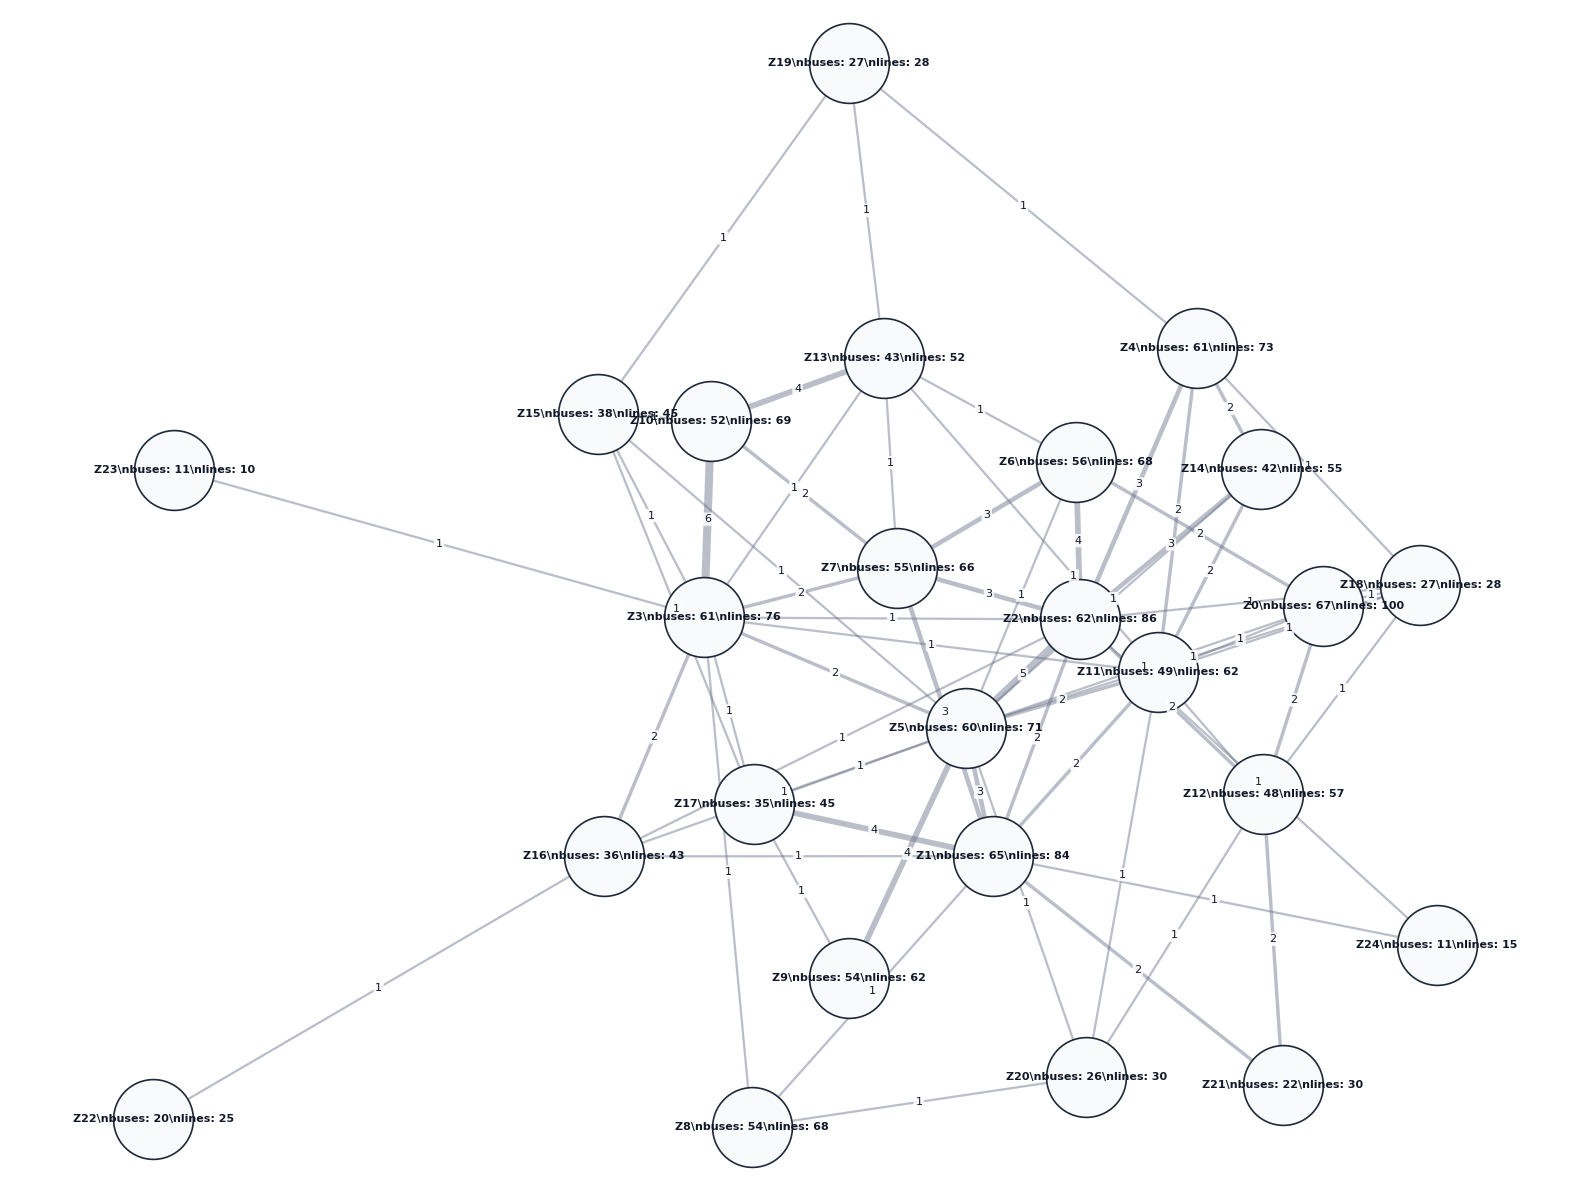

BPA zone graph: 25 zones, 66 inter-zone connections
Saved BPA zone connectivity graph to /home/aj/phd/nyiso-data/src-bpa/output/zone_connectivity_graph_fr_bpa.pdf


In [9]:
# BPA zone connectivity graph visualization.
from collections import Counter
from pathlib import Path

import igraph as ig
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ZONE_GRAPH_LAYOUT = "fr"
ZONE_GRAPH_OUTPUT_PATH = OUTPUT_DIR / "zone_connectivity_graph_fr_bpa.pdf"

if not {"graph", "bus_to_zone", "edge_zone_df"}.issubset(globals()):
    raise RuntimeError(
        "Run the preceding BPA normalization and graph-building cells first."
    )

zone_ids = sorted({int(zone) for zone in bus_to_zone.values()})
zone_to_index = {zone_id: index for index, zone_id in enumerate(zone_ids)}
bus_counts = Counter(int(zone) for zone in bus_to_zone.values())

endpoint_zones = edge_zone_df[["from_zone", "to_zone"]].astype(int)
intra_counts = (
    endpoint_zones[endpoint_zones["from_zone"] == endpoint_zones["to_zone"]]
    .groupby("from_zone")
    .size()
    .to_dict()
)
inter_edges = endpoint_zones[
    endpoint_zones["from_zone"] != endpoint_zones["to_zone"]
].copy()
inter_edges["zone_a"] = inter_edges[["from_zone", "to_zone"]].min(axis=1)
inter_edges["zone_b"] = inter_edges[["from_zone", "to_zone"]].max(axis=1)
inter_counts = (
    inter_edges.groupby(["zone_a", "zone_b"])
    .size()
    .reset_index(name="edge_count")
    .sort_values(["edge_count", "zone_a", "zone_b"], ascending=[False, True, True])
)

zone_graph = ig.Graph(n=len(zone_ids), directed=False)
zone_graph.vs["zone_id"] = zone_ids
zone_graph.vs["bus_count"] = [bus_counts.get(zone, 0) for zone in zone_ids]
zone_graph.vs["intra_edge_count"] = [
    int(intra_counts.get(zone, 0)) for zone in zone_ids
]
zone_graph.vs["label"] = [
    f"Z{zone}\\nbuses: {bus_counts.get(zone, 0)}\\n"
    f"lines: {intra_counts.get(zone, 0)}"
    for zone in zone_ids
]

if not inter_counts.empty:
    zone_graph.add_edges(
        [
            (zone_to_index[int(row.zone_a)], zone_to_index[int(row.zone_b)])
            for row in inter_counts.itertuples(index=False)
        ]
    )
    zone_graph.es["edge_count"] = [
        int(row.edge_count) for row in inter_counts.itertuples(index=False)
    ]
else:
    zone_graph.es["edge_count"] = []

weights = zone_graph.es["edge_count"] if zone_graph.ecount() else None
layout = zone_graph.layout_fruchterman_reingold(
    weights=weights,
    niter=1000,
    start_temp=np.sqrt(max(zone_graph.vcount(), 1)) * 1.5,
)
coords = np.asarray(layout.coords, dtype=float)

fig, ax = plt.subplots(figsize=(16, 12))
max_edge_count = max(zone_graph.es["edge_count"] or [1])
for edge, edge_count in zip(zone_graph.es, zone_graph.es["edge_count"]):
    source, target = edge.tuple
    start, end = coords[source], coords[target]
    ax.plot(
        [start[0], end[0]],
        [start[1], end[1]],
        color="#667085",
        alpha=0.45,
        linewidth=0.8 + 5.0 * edge_count / max_edge_count,
        zorder=1,
    )
    midpoint = (start + end) / 2
    ax.text(
        midpoint[0],
        midpoint[1],
        str(edge_count),
        ha="center",
        va="center",
        fontsize=8,
        color="#111827",
        bbox={
            "boxstyle": "round,pad=0.15",
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.85,
        },
        zorder=3,
    )

ax.scatter(
    coords[:, 0],
    coords[:, 1],
    s=3300,
    facecolor="#f8fafc",
    edgecolor="#1f2937",
    linewidth=1.2,
    zorder=2,
)
for vertex, (x_coord, y_coord) in zip(zone_graph.vs, coords):
    ax.text(
        x_coord,
        y_coord,
        vertex["label"],
        ha="center",
        va="center",
        fontsize=8,
        fontweight="bold",
        color="#111827",
        zorder=4,
    )

ax.set_aspect("equal", adjustable="datalim")
ax.set_axis_off()
ZONE_GRAPH_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
fig.tight_layout()
fig.savefig(ZONE_GRAPH_OUTPUT_PATH, dpi=300, bbox_inches="tight")
plt.show()
print(
    f"BPA zone graph: {zone_graph.vcount()} zones, "
    f"{zone_graph.ecount()} inter-zone connections"
)
print(f"Saved BPA zone connectivity graph to {ZONE_GRAPH_OUTPUT_PATH.resolve()}")